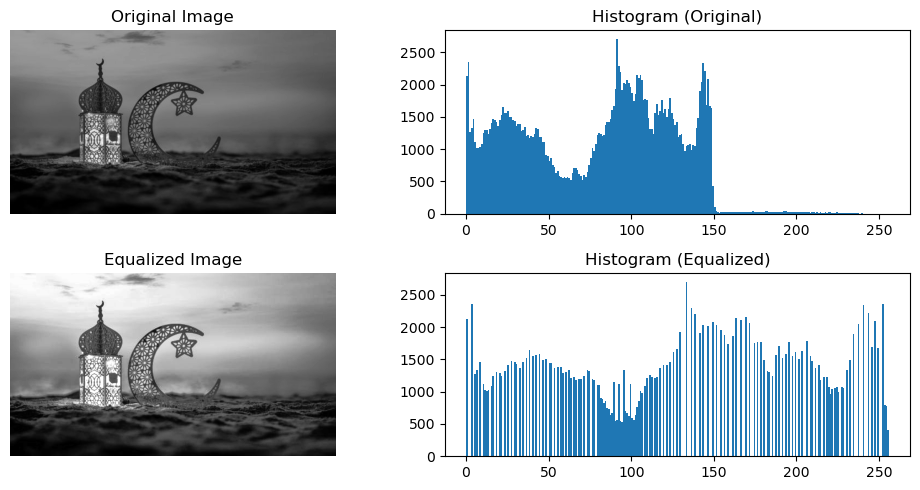

In [2]:
import cv2
import matplotlib.pyplot as plt

# Read image (color first)
image = cv2.imread("/Users/210721/Downloads/5.jpg")

if image is None:
    print("Error: Image not found!")
    exit()

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply histogram equalization
equalized_image = cv2.equalizeHist(gray)

# Display
plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.imshow(gray, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2,2,2)
plt.hist(gray.ravel(), 256, [0,256])
plt.title('Histogram (Original)')

plt.subplot(2,2,3)
plt.imshow(equalized_image, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')

plt.subplot(2,2,4)
plt.hist(equalized_image.ravel(), 256, [0,256])
plt.title('Histogram (Equalized)')

plt.tight_layout()
plt.show()

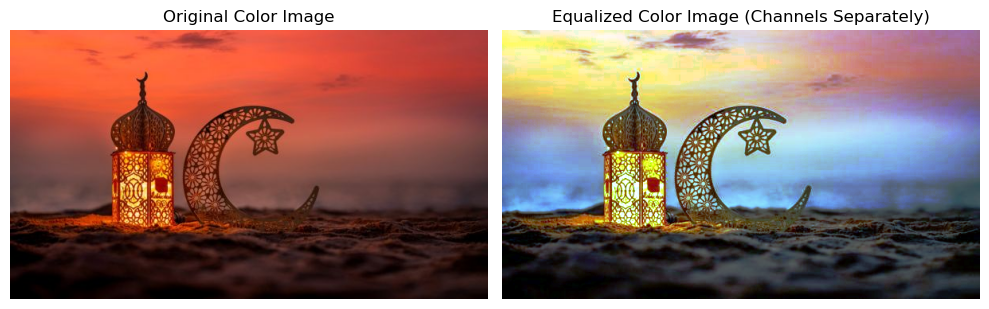

In [3]:
import cv2
import matplotlib.pyplot as plt

# Read color image
color_image = cv2.imread("/Users/210721/Downloads/5.jpg")

if color_image is None:
    print("Error: Image not found!")
    exit()

# Split into B, G, R channels (OpenCV uses BGR)
b, g, r = cv2.split(color_image)

# Apply histogram equalization to each channel
equalized_b = cv2.equalizeHist(b)
equalized_g = cv2.equalizeHist(g)
equalized_r = cv2.equalizeHist(r)

# Merge equalized channels
equalized_color_image = cv2.merge((equalized_b, equalized_g, equalized_r))

# Display images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
plt.title("Original Color Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(equalized_color_image, cv2.COLOR_BGR2RGB))
plt.title("Equalized Color Image (Channels Separately)")
plt.axis('off')

plt.tight_layout()
plt.show()

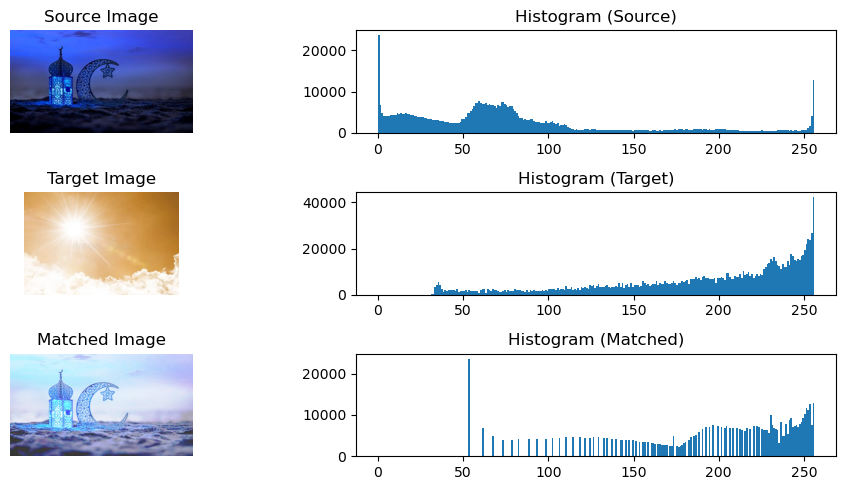

In [2]:
import cv2
import numpy as np
from skimage import exposure
import matplotlib.pyplot as plt

# Read two grayscale images
image_source = cv2.imread("/Users/210721/Downloads/5.jpg")
image_target = cv2.imread("/Users/210721/Downloads/66.jpg")

if image_source is None or image_target is None:
    print("Error: One of the images not found!")
    exit()

# Perform histogram matching
matched_image = exposure.match_histograms(image_source, image_target)

# Convert result to uint8 (VERY IMPORTANT)
matched_image = np.clip(matched_image, 0, 255).astype('uint8')

# Display images and histograms
plt.figure(figsize=(15,5))

# Source
plt.subplot(3,3,1)
plt.imshow(image_source, cmap='gray')
plt.title("Source Image")
plt.axis('off')

plt.subplot(3,3,2)
plt.hist(image_source.ravel(), 256, [0,256])
plt.title("Histogram (Source)")

# Target
plt.subplot(3,3,4)
plt.imshow(image_target, cmap='gray')
plt.title("Target Image")
plt.axis('off')

plt.subplot(3,3,5)
plt.hist(image_target.ravel(), 256, [0,256])
plt.title("Histogram (Target)")

# Matched
plt.subplot(3,3,7)
plt.imshow(matched_image, cmap='gray')
plt.title("Matched Image")
plt.axis('off')

plt.subplot(3,3,8)
plt.hist(matched_image.ravel(), 256, [0,256])
plt.title("Histogram (Matched)")

plt.tight_layout()
plt.show()

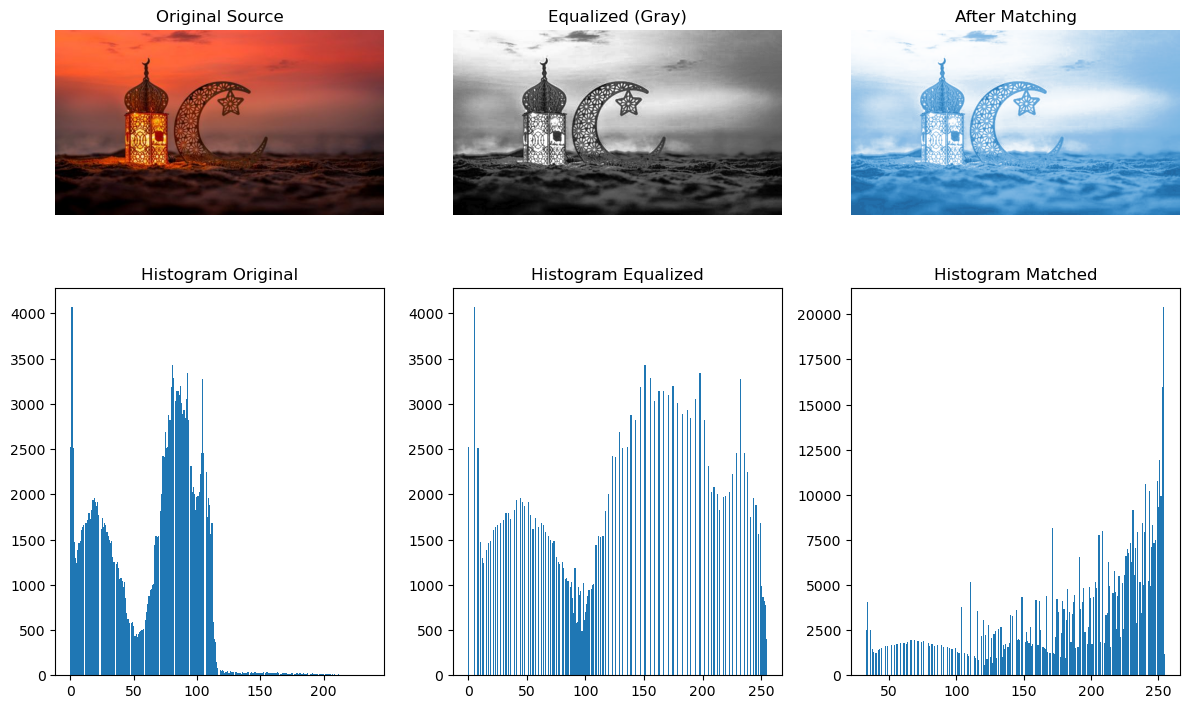

In [5]:
import cv2
import numpy as np
from skimage import exposure
import matplotlib.pyplot as plt

source = cv2.imread("/Users/210721/Downloads/5.jpg")
target = cv2.imread("/Users/210721/Downloads/66.jpg")

source_rgb = cv2.cvtColor(source, cv2.COLOR_BGR2RGB)
target_rgb = cv2.cvtColor(target, cv2.COLOR_BGR2RGB)

source_gray = cv2.cvtColor(source, cv2.COLOR_RGB2GRAY)

equalized_gray = cv2.equalizeHist(source_gray)

equalized_rgb = cv2.cvtColor(equalized_gray, cv2.COLOR_GRAY2RGB)

matched = exposure.match_histograms(equalized_rgb, target_rgb, channel_axis=-1)

plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(source_rgb)
plt.title('Original Source')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(equalized_gray, cmap='gray')
plt.title('Equalized (Gray)')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(matched)
plt.title('After Matching')
plt.axis('off')

plt.subplot(2,3,4)
plt.hist(source_gray.ravel(), bins=256)
plt.title('Histogram Original')

plt.subplot(2,3,5)
plt.hist(equalized_gray.ravel(), bins=256)
plt.title('Histogram Equalized')

plt.subplot(2,3,6)
plt.hist(matched.ravel(), bins=256)
plt.title('Histogram Matched')

plt.tight_layout()
plt.savefig('result.png', dpi=300)
plt.show()